# Advanced Time Series Forecasting, Optimization and Explainability

## Final Project — Advanced Topics in Deep Learning (2025/2026)

### Developed by:

- António Cruz (140129)
- Cátia Brás (120093)
- Ricardo Kyaseller (95813)

## 1. Introduction and Project Goals

This project builds upon the Time Series Modelling mini-project to develop a systematic, optimized, and well-analysed forecasting system for air temperature prediction using the Jena Climate dataset. While the mini-project focused on exploratory modelling and understanding different design choices, this Final Project elevates performance to a primary objective, achieved through systematic optimization and supported by rigorous analysis.

The core forecasting task is a **multivariate-input, univariate-output, multi-step prediction** problem: given a window of 120 hours of historical meteorological measurements (temperature, pressure, humidity, wind speed, maximum wind speed, and wind direction), the system predicts the air temperature for the next 24 hours.

Our pipeline integrates the following advanced techniques:

- **Baseline Deep Learning Model (GRU):** A configurable multi-layer GRU architecture serves as the reference model against which all improvements are measured. The baseline incorporates regularization (L2, dropout, Gaussian noise), gradient clipping, and modern training strategies (AdamW optimizer, Huber loss).

- **Evolutionary Optimization:** A genetic algorithm (GA) automatically searches over an end-to-end pipeline configuration space, jointly optimizing model hyperparameters, architectural choices (number of layers, units, activation functions), training settings (optimizer, learning rate, loss function, batch size), preprocessing strategy (scaler type), and regularization. The top EA individuals are combined into an ensemble for improved forecasting accuracy.

- **Synthetic Data Generation (TimeGAN):** A Time-series Generative Adversarial Network generates realistic synthetic weather sequences from the training set, demonstrating the feasibility of data augmentation without information leakage.

- **Explainable AI (XAI):** Both global and local explanation methods are applied to understand which input features and temporal patterns drive the model's predictions, providing interpretability and trust in the forecasting system.

- **Efficiency and Resource Analysis:** Training time, inference latency, parameter counts, and memory usage are profiled across model configurations, enabling an informed analysis of accuracy–efficiency trade-offs.

The remainder of this report is organized as follows: Section 2 describes the experimental setup and reproducibility measures; Section 3 presents the dataset and problem formulation; Sections 4–6 cover data preparation, feature engineering, and the windowing pipeline; Section 7 establishes the baseline models; Section 8 details the TimeGAN synthetic data generation; Section 9 presents the evolutionary optimization process; Section 10 covers final model retraining, ensembling, and selection; Sections 11–12 present the explainability and efficiency analyses; and Sections 13–14 provide the comparative discussion and conclusion.

## 2. Environment, Reproducibility and Experimental Setup

### 2.1 Libraries Import

The following cell imports all libraries used throughout the notebook. Core dependencies include TensorFlow/Keras for deep learning, NumPy/Pandas for data manipulation, Matplotlib for visualization, and scikit-learn for evaluation metrics.

The project is implemented in Python 3.12 using the following key libraries:

| Library | Purpose |
|---------|---------|
| TensorFlow / Keras | Deep learning framework for GRU models and TimeGAN |
| NumPy, Pandas | Data manipulation and numerical computation |
| scikit-learn | Scalers (StandardScaler, RobustScaler, MinMaxScaler) and evaluation metrics |
| Matplotlib, Seaborn | Visualization |
| psutil | System-level memory and resource monitoring |

All dependencies are specified in `requirements.txt` for reproducibility.

In [1]:
import os
import sys
import random
import warnings
from pathlib import Path

# Suppress TensorFlow informational logs and oneDNN messages
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

### 2.2 Reproducibility

To ensure reproducible results across runs, we set a global random seed (`SEED = 42`) applied consistently to:

- Python's built-in `random` module,
- NumPy's random number generator,
- TensorFlow's global and operation-level random seeds.

This is handled by the utility function `set_global_seed()` from `src.utils.env`. While perfect determinism on GPU is not guaranteed due to non-deterministic reduction operations, fixing all controllable seeds ensures that results are reproducible to a high degree.

### 2.3 GPU Configuration

TensorFlow's GPU memory growth is enabled via `enable_gpu_memory_growth()`, which allows the framework to allocate memory incrementally rather than reserving the full GPU memory upfront. This prevents out-of-memory errors when running multiple models (as required during evolutionary search) and enables more efficient resource sharing.

### 2.4 Project Structure

The codebase follows a modular design, separating concerns across distinct packages:

```
src/
├── features/       # Feature engineering, scaling, windowing
├── models/         # GRU model builder and training utilities
├── evolution/      # Evolutionary search: search space, operators, fitness
├── gan/            # TimeGAN architecture, config, data preparation
└── utils/          # Environment setup, profiling tools
```

This modular approach allows the notebook to focus on experimental orchestration and analysis while keeping reusable logic in tested, importable modules.

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/home/logus/env/iscte/taap_p4


In [4]:
from src.utils.env import set_global_seed, enable_gpu_memory_growth, get_device_info

SEED = 42
set_global_seed(SEED)
enable_gpu_memory_growth()

print(get_device_info())

{'tensorflow_version': '2.21.0', 'num_gpus': 1, 'gpus': ['/physical_device:GPU:0'], 'num_cpus': 1, 'cpus': ['/physical_device:CPU:0']}


## 3. Dataset and Problem Definition

### 3.1 Dataset Description

The Jena Climate dataset contains meteorological measurements collected at a weather station in Jena, Germany, between January 2009 and December 2016. The raw data is sampled every 10 minutes, yielding approximately 420,000 observations across 15 meteorological variables.

The dataset is publicly available at: https://keras.io/examples/timeseries/timeseries_weather_forecasting

In [5]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "src" / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists?", DATA_DIR.exists())

PROJECT_ROOT: /home/logus/env/iscte/taap_p4
DATA_DIR: /home/logus/env/iscte/taap_p4/src/data
DATA_DIR exists? True


In [6]:
DATASET_PATH = DATA_DIR / "jena_climate_2009_2016.csv"

df = pd.read_csv(DATASET_PATH)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### 3.2 Initial Inspection and Quality Assurance

Upon loading, we performed the following quality checks:

- **Duplicate detection:** Verified that no duplicate timestamps exist in the raw data.
- **Missing value analysis:** Checked for NaN entries across all columns.
- **Temporal ordering:** Confirmed that the dataset is strictly ordered by time, with no gaps or inversions in the datetime index.
- **Sampling regularity:** Examined the distribution of time deltas between consecutive observations to detect any irregularities in the 10-minute sampling frequency.

In [7]:
print("Dataset path:", DATASET_PATH)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInfo:")
df.info()

Dataset path: /home/logus/env/iscte/taap_p4/src/data/jena_climate_2009_2016.csv
Shape: (420551, 15)

Columns:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2

After loading the raw dataset, we perform a series of quality checks to ensure data integrity before any transformations. Specifically, we verify the presence of duplicated rows and inspect all columns for missing values. Any duplicated observations are removed to avoid biasing the resampling step that follows. This is a standard practice in time series preprocessing — duplicate timestamps can arise from logging artifacts and must be eliminated to ensure a consistent temporal index.

In [8]:
print("Duplicated rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isna().sum())

Duplicated rows: 327

Missing values per column:
Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


In [9]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Duplicated rows after cleanup:", df.duplicated().sum())

Shape after removing duplicates: (420224, 15)
Duplicated rows after cleanup: 0


### 3.3 Temporal Resampling

The raw 10-minute resolution was resampled to **1-hour intervals** using mean aggregation. This decision reduces the dataset size by a factor of 6 (from ~420k to ~70k observations) while preserving the dominant meteorological patterns, which operate on hourly-to-daily timescales. Hourly resolution also aligns the lookback and horizon parameters with intuitive units (hours), making the forecasting task more interpretable.

After resampling, any rows with NaN values (resulting from incomplete hourly bins at dataset boundaries) were dropped.

In [10]:
df["Date Time"] = pd.to_datetime(df["Date Time"], dayfirst=True)
df = df.sort_values("Date Time").reset_index(drop=True)

print(df["Date Time"].min(), "->", df["Date Time"].max())
df[["Date Time"]].head()

2009-01-01 00:10:00 -> 2017-01-01 00:00:00


,Date Time
0,2009-01-01 00:10:00
1,2009-01-01 00:20:00
2,2009-01-01 00:30:00
3,2009-01-01 00:40:00
4,2009-01-01 00:50:00


In [11]:
df["Date Time"].diff().value_counts().head(10)

Date Time
0 days 00:10:00    420218
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64

### 3.4 Hourly Resampling

The actual resampling operation uses Pandas' `resample("1h").mean()` on the datetime-indexed dataframe, aggregating all 10-minute observations within each hourly bin into their arithmetic mean. This is applied uniformly across all meteorological variables. Mean aggregation was chosen over alternatives (e.g., first/last value, median) because it preserves the central tendency of each hour's measurements while smoothing out sub-hourly noise that is irrelevant for the 24-hour forecasting task.

In [12]:
df_hourly = (
    df.set_index("Date Time")
      .resample("1h")
      .mean()
      .reset_index()
)

print("Original shape:", df.shape)
print("Hourly shape:", df_hourly.shape)
print(df_hourly.head())

Original shape: (420224, 15)
Hourly shape: (70129, 15)
            Date Time    p (mbar)  T (degC)    Tpot (K)  Tdew (degC)  \
0 2009-01-01 00:00:00  996.528000 -8.304000  265.118000    -9.120000   
1 2009-01-01 01:00:00  996.525000 -8.065000  265.361667    -8.861667   
2 2009-01-01 02:00:00  996.745000 -8.763333  264.645000    -9.610000   
3 2009-01-01 03:00:00  996.986667 -8.896667  264.491667    -9.786667   
4 2009-01-01 04:00:00  997.158333 -9.348333  264.026667   -10.345000   

      rh (%)  VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
0  93.780000      3.260000      3.058000      0.202000   1.910000   
1  93.933333      3.323333      3.121667      0.201667   1.951667   
2  93.533333      3.145000      2.940000      0.201667   1.836667   
3  93.200000      3.111667      2.898333      0.210000   1.811667   
4  92.383333      3.001667      2.775000      0.231667   1.733333   

   H2OC (mmol/mol)  rho (g/m**3)  wv (m/s)  max. wv (m/s)    wd (deg)  
0         3.068000   1309

### 3.5 Post-Resampling Quality Check

After resampling, we re-validate the dataset to ensure the operation did not introduce artifacts. We verify that no duplicate hourly timestamps exist, that the time delta between consecutive rows is consistently 1 hour, and that any missing values (from incomplete hourly bins at the boundaries of data gaps) are identified and quantified. This step is critical because the sliding window approach used later assumes a regular, gap-free time series.

In [13]:
print("Missing values after hourly resampling:")
print(df_hourly.isna().sum())

print("\nDuplicated timestamps after resampling:", df_hourly["Date Time"].duplicated().sum())

print("\nTime step distribution after resampling:")
print(df_hourly["Date Time"].diff().value_counts().head(10))

Missing values after hourly resampling:
Date Time           0
p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           88
max. wv (m/s)      88
wd (deg)           88
dtype: int64

Duplicated timestamps after resampling: 0

Time step distribution after resampling:
Date Time
0 days 01:00:00    70128
Name: count, dtype: int64


### 3.6 Handling Missing Values After Resampling

Any rows containing NaN values after resampling are dropped. Since the original dataset has near-complete 10-minute coverage across the 2009–2016 period, the number of affected rows is minimal (88 out of ~70,000) and does not introduce meaningful temporal gaps. Dropping these rows is preferred over imputation because the affected bins are concentrated at dataset boundaries and isolated gaps, where interpolation would risk introducing artificial patterns.

In [14]:
df_hourly = df_hourly.dropna().reset_index(drop=True)

print("Shape after dropping NaNs:", df_hourly.shape)
print("\nMissing values after cleanup:")
print(df_hourly.isna().sum().sum())
print("\nTime step distribution after cleanup:")
print(df_hourly["Date Time"].diff().value_counts().head())

Shape after dropping NaNs: (70041, 15)

Missing values after cleanup:
0

Time step distribution after cleanup:
Date Time
0 days 01:00:00    70038
0 days 16:00:00        1
3 days 02:00:00        1
Name: count, dtype: int64


### 3.7 Forecasting Task and Variable Selection

Following the project specification, we retain 6 meteorological variables plus the datetime reference: `T (degC)` (air temperature, the target), `p (mbar)` (atmospheric pressure), `rh (%)` (relative humidity), `wv (m/s)` (wind speed), `max. wv (m/s)` (maximum wind speed), and `wd (deg)` (wind direction). All other variables from the original 15-column dataset are excluded to maintain a focused and non-trivial forecasting problem.

This defines a **multivariate-input, univariate-output, multi-step** forecasting problem: the model receives a 5-day window of multi-sensor weather data (120 hourly time steps across all features) and must predict the air temperature trajectory for the next 24 hours. The multivariate input ensures the model can leverage cross-variable dependencies — for instance, the relationship between falling pressure and subsequent temperature changes driven by weather fronts.

In [15]:
selected_columns = [
    "Date Time",
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

df_model = df_hourly[selected_columns].copy()

print("Selected columns:")
print(df_model.columns.tolist())
print("\nShape:", df_model.shape)
df_model.head()

Selected columns:
['Date Time', 'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Shape: (70041, 7)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


## 4. Data Initial Preparation

### 4.1 Target Definition and Base Modeling DataFrame

The target variable is defined as `T (degC)` — air temperature in degrees Celsius. This is the only variable the model must predict in the output window. The `Date Time` column serves as the temporal reference for feature engineering (extracting hour-of-day and day-of-year) but is not used directly as a model input. The remaining meteorological variables (`p`, `rh`, `wv`, `max. wv`, `wd`) form the exogenous covariates that provide atmospheric context for the temperature forecast.

In [16]:
TARGET_COL = "T (degC)"
TIME_COL = "Date Time"

feature_cols = [col for col in df_model.columns if col not in [TIME_COL]]
input_feature_cols = [col for col in feature_cols]

print("Target:", TARGET_COL)
print("Time column:", TIME_COL)
print("Input features:", input_feature_cols)
print("Number of input features:", len(input_feature_cols))

Target: T (degC)
Time column: Date Time
Input features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Number of input features: 6


### 4.2 Base Forecasting Data Overview

We inspect the prepared dataframe to confirm shape, date range, and column integrity before proceeding to feature engineering. The dataset at this stage contains 70,041 hourly observations spanning from January 2009 to January 2017, with 7 columns (datetime + 6 meteorological variables). This verification step ensures that no data was inadvertently lost during the resampling and cleaning process.

In [17]:
print(df_model.head())
print("\nShape:", df_model.shape)
print("\nDate range:", df_model[TIME_COL].min(), "->", df_model[TIME_COL].max())

            Date Time  T (degC)    p (mbar)     rh (%)  wv (m/s)  \
0 2009-01-01 00:00:00 -8.304000  996.528000  93.780000  0.520000   
1 2009-01-01 01:00:00 -8.065000  996.525000  93.933333  0.316667   
2 2009-01-01 02:00:00 -8.763333  996.745000  93.533333  0.248333   
3 2009-01-01 03:00:00 -8.896667  996.986667  93.200000  0.176667   
4 2009-01-01 04:00:00 -9.348333  997.158333  92.383333  0.290000   

   max. wv (m/s)    wd (deg)  
0       1.002000  174.460000  
1       0.711667  172.416667  
2       0.606667  196.816667  
3       0.606667  157.083333  
4       0.670000  150.093333  

Shape: (70041, 7)

Date range: 2009-01-01 00:00:00 -> 2017-01-01 00:00:00


## 5. Feature Engineering

Two families of derived features are introduced to enrich the input representation: **cyclical temporal encodings** and **wind-derived features**. The goal is to provide the neural network with representations that respect the physical structure of the data — cyclic quantities are encoded cyclically, and vector quantities are decomposed into Cartesian components. All feature engineering is implemented in `src.features.engineering` for reproducibility.

In [18]:
from src.features.engineering import (
    add_time_features,
    add_wind_features,
    get_final_feature_columns,
)
from src.features.windowing import make_windows
from src.models.gru import build_gru_model

### 5.1 Cyclical Time Features

Hour-of-day and day-of-year carry strong periodic signals (diurnal and seasonal cycles). Encoding them as raw integers would introduce artificial discontinuities (e.g., hour 23 far from hour 0). We apply a sine–cosine encoding that maps each cyclic variable to a point on the unit circle, ensuring smooth transitions at boundaries:
- `hour_sin`, `hour_cos` — diurnal cycle (period = 24h)
- `doy_sin`, `doy_cos` — seasonal cycle (period = 365.25 days)

In [19]:
df_feat = add_time_features(df_model, time_col=TIME_COL)

df_feat[[
    TIME_COL, "hour", "dayofyear",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos"
]].head()

,Date Time,hour,dayofyear,hour_sin,hour_cos,doy_sin,doy_cos
0,2009-01-01 00:00:00,0,1,0.000000,1.000000,0.017202,0.999852
1,2009-01-01 01:00:00,1,1,0.258819,0.965926,0.017202,0.999852
2,2009-01-01 02:00:00,2,1,0.500000,0.866025,0.017202,0.999852
3,2009-01-01 03:00:00,3,1,0.707107,0.707107,0.017202,0.999852
4,2009-01-01 04:00:00,4,1,0.866025,0.500000,0.017202,0.999852


### 5.2 Wind-Derived Features

Wind direction in degrees is inherently circular and difficult for neural networks to interpret directly. We derive six features:
- `wd_sin`, `wd_cos` — cyclic encoding of wind direction
- `wx`, `wy` — Cartesian decomposition of wind vector (speed × cos/sin of direction), replacing the polar representation with a form neural networks process more naturally
- `wind_gap` — difference between max and sustained wind speed (gust intensity)
- `gust_ratio` — ratio of max to sustained wind speed (relative gust strength, with ε = 10⁻⁶ for numerical stability)

In [20]:
df_feat = add_wind_features(df_feat)

df_feat[[
    TIME_COL, "wv (m/s)", "max. wv (m/s)", "wd (deg)",
    "wd_sin", "wd_cos", "wx", "wy", "wind_gap", "gust_ratio"
]].head()

,Date Time,wv (m/s),max. wv (m/s),wd (deg),wd_sin,wd_cos,wx,wy,wind_gap,gust_ratio
0,2009-01-01 00:00:00,0.520000,1.002000,174.460000,0.096541,-0.995329,-0.517571,0.050201,0.482000,1.926919
1,2009-01-01 01:00:00,0.316667,0.711667,172.416667,0.131968,-0.991254,-0.313897,0.041790,0.395000,2.247361
2,2009-01-01 02:00:00,0.248333,0.606667,196.816667,-0.289310,-0.957235,-0.237713,-0.071845,0.358333,2.442943
3,2009-01-01 03:00:00,0.176667,0.606667,157.083333,0.389392,-0.921072,-0.162723,0.068793,0.430000,3.433943
4,2009-01-01 04:00:00,0.290000,0.670000,150.093333,0.498589,-0.866839,-0.251383,0.144591,0.380000,2.310337


### 5.3 Final Feature Set for Modeling

The complete input feature vector contains **16 dimensions**: 6 original meteorological variables + 4 cyclical temporal encodings + 6 wind-derived features. This feature set is defined in `get_final_feature_columns()` and used consistently across all experiments — baseline, evolutionary optimization, and synthetic data generation. The expansion from 6 to 16 features provides the model with richer representations without introducing external data sources or violating the variable selection constraints of the project specification.

In [21]:
final_feature_cols = get_final_feature_columns()

print("Number of modeling features:", len(final_feature_cols))
print(final_feature_cols)

Number of modeling features: 16
['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wd_sin', 'wd_cos', 'wx', 'wy', 'wind_gap', 'gust_ratio']


## 6. Split, Scaling and Windowing

### 6.1 Temporal Train/Validation/Test Split

The dataset is split chronologically (70% / 15% / 15%) with **no shuffling** — the split respects temporal order to prevent data leakage. The training set covers the earliest years, followed by validation, with the most recent data reserved for testing. This mirrors a realistic deployment scenario.

In [22]:
n = len(df_feat)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_feat.iloc[:train_end].copy()
df_val = df_feat.iloc[train_end:val_end].copy()
df_test = df_feat.iloc[val_end:].copy()

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

Train shape: (49028, 19)
Validation shape: (10506, 19)
Test shape: (10507, 19)


### 6.2 Feature Scaling

All input features are normalized using **StandardScaler** (zero mean, unit variance) as the baseline strategy. The scaler is fit exclusively on the training set and then applied via `transform` to the validation and test sets, preventing any information leakage from future data into the scaling parameters. This is a critical design choice — fitting the scaler on the full dataset would allow statistics from the validation and test periods to influence the training data representation, violating the temporal split.

The evolutionary optimization also searches over the scaler type, considering StandardScaler, RobustScaler (median/IQR-based, robust to outliers), and MinMaxScaler (scales to [0, 1]). This allows the GA to discover whether a different normalization strategy benefits specific model configurations.

In [23]:
from src.features.scaling import get_scaler

In [24]:
SCALER_NAME = "standard"   # baseline oficial; no EA poderá ser standard/robust/minmax
scaler = get_scaler(SCALER_NAME)

X_train_df = df_train[final_feature_cols].copy()
X_val_df = df_val[final_feature_cols].copy()
X_test_df = df_test[final_feature_cols].copy()

X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)
X_test_scaled = scaler.transform(X_test_df)

print("Scaler:", SCALER_NAME)
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaler: standard
Scaled train shape: (49028, 16)
Scaled val shape: (10506, 16)
Scaled test shape: (10507, 16)


### 6.3 Target Index for Forecasting

We identify the position of `T (degC)` within the 16-feature vector. This index is used during the windowing step to extract only the temperature column for the output sequence **y**, while keeping all 16 features in the input tensor **X**. This separation is what makes the problem multivariate-input but univariate-output: the model sees all meteorological context as input but is only evaluated on its ability to predict future temperature.

In [25]:
target_idx = final_feature_cols.index(TARGET_COL)

print("Target column:", TARGET_COL)
print("Target index:", target_idx)

Target column: T (degC)
Target index: 0


### 6.4 Supervised Windowing

The scaled data is converted into supervised learning samples using a sliding window:
- **Input (X):** `(LOOKBACK, 16)` = 120 consecutive hourly observations across all features (5 days of context)
- **Output (y):** `(HORIZON,)` = 24 hourly temperature values to predict (1 day ahead)

The window slides by one time step, generating the maximum number of training samples.

In [26]:
from src.features.windowing import make_windows

In [27]:
LOOKBACK = 120
HORIZON = 24

X_train, y_train = make_windows(X_train_scaled, target_idx, LOOKBACK, HORIZON)
X_val, y_val = make_windows(X_val_scaled, target_idx, LOOKBACK, HORIZON)
X_test, y_test = make_windows(X_test_scaled, target_idx, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (48885, 120, 16) y_train: (48885, 24)
X_val: (10363, 120, 16) y_val: (10363, 24)
X_test: (10364, 120, 16) y_test: (10364, 24)


### 6.5 Windowed Data Sanity Check

We verify the shapes of all windowed arrays to confirm correct dimensionality and consistency between input and output samples across train, validation, and test splits. The expected shapes are: input `(N, 120, 16)` — N samples, each with 120 hourly time steps across 16 features; output `(N, 24)` — N corresponding 24-hour temperature forecast targets. This verification catches common off-by-one errors in window construction that would silently corrupt the training process.

In [28]:
print("Input shape:", X_train.shape[1:])
print("Forecast horizon:", y_train.shape[1])
print("Number of input features:", X_train.shape[2])

print("\nExample input window shape:", X_train[0].shape)
print("Example target shape:", y_train[0].shape)
print("First 5 target values (scaled):", y_train[0][:5])

Input shape: (120, 16)
Forecast horizon: 24
Number of input features: 16

Example input window shape: (120, 16)
Example target shape: (24,)
First 5 target values (scaled): [-2.55218147 -2.61156348 -2.64453206 -2.68540539 -2.73726824]


## 7. Baseline Models

Two baseline models are established as reference points for evaluating all subsequent improvements. The **persistence baseline** provides the lowest bar — the performance of a no-skill forecast that any learned model must surpass. The **GRU baseline** represents a carefully designed deep learning model with modern training practices, serving as the benchmark against which the evolutionary optimization is measured.

### 7.1 Persistence Baseline

The simplest possible forecast: repeat the last observed temperature value across the entire 24-hour horizon. This naive baseline provides a scale-aware reference — any learned model that fails to beat persistence adds no value. We first build a simple GRU as a quick sanity check, then proceed to the official configurable baseline in Section 7.2.

In [29]:
def persistence_forecast(X):
    # Repeats the last observed target value across the full forecast horizon
    last_temp = X[:, -1, target_idx]
    return np.repeat(last_temp[:, None], HORIZON, axis=1)

y_pred_persistence = persistence_forecast(X_test)

print("Persistence prediction shape:", y_pred_persistence.shape)
print("First prediction:", y_pred_persistence[0][:5])

Persistence prediction shape: (10364, 24)
First prediction: [-0.04174932 -0.04174932 -0.04174932 -0.04174932 -0.04174932]


In [30]:
persistence_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_persistence.flatten())
persistence_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_persistence.flatten()))

print("Persistence MAE (scaled):", persistence_mae_scaled)
print("Persistence RMSE (scaled):", persistence_rmse_scaled)

Persistence MAE (scaled): 0.3636531434000367
Persistence RMSE (scaled): 0.4921206134926399


In [31]:
def build_gru_baseline(input_shape, horizon):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(horizon)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

gru_baseline = build_gru_baseline(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    horizon=HORIZON
)

gru_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,464 (83.84 KB)

 Trainable params: 21,464 (83.84 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = gru_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.1371 - mae: 0.2715 - val_loss: 0.0785 - val_mae: 0.2119
Epoch 2/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0831 - mae: 0.2212 - val_loss: 0.0737 - val_mae: 0.2043
Epoch 3/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0771 - mae: 0.2125 - val_loss: 0.0725 - val_mae: 0.2018
Epoch 4/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0731 - mae: 0.2064 - val_loss: 0.0713 - val_mae: 0.1994
Epoch 5/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0700 - mae: 0.2017 - val_loss: 0.0718 - val_mae: 0.1995
Epoch 6/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0673 - mae: 0.1979 - val_loss: 0.0724 - val_mae: 0.1998
Epoch 7/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0647 - mae: 0.1944 - val_loss: 0.0748 - val_mae: 0.2037
Epoch 8/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0619 - mae: 0.1905 - val_loss: 0.0749 - val_mae: 0.2020
Epoch 9/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/

In [33]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:5])

Prediction shape: (10364, 24)
First prediction: [-0.1424625  -0.20059904 -0.15984489 -0.11215417 -0.00340318]


In [34]:
gru_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_gru.flatten())
gru_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_gru.flatten()))

print("GRU MAE (scaled):", gru_mae_scaled)
print("GRU RMSE (scaled):", gru_rmse_scaled)

GRU MAE (scaled): 0.19167879244352198
GRU RMSE (scaled): 0.25372439313368134


### 7.2 GRU Baseline (Official)

The official baseline uses `build_gru_model()` from `src.models.gru` — a configurable 2-layer GRU with AdamW optimizer, Huber loss (δ=1.0), L2 regularization, gradient clipping, and an intermediate dense layer. Training uses early stopping (patience=6) and learning rate reduction (patience=3, factor=0.5) via `train_model()` from `src.models.train_eval`.

In [35]:
from src.models.gru import build_gru_model

In [36]:
BASELINE_CFG = {
    "n_layers": 2,
    "units1": 96,
    "units2": 64,
    "units3": 96,
    "dropout": 0.0,
    "l2": 1e-6,
    "dense_units": 256,
    "dense_activation": "relu",
    "learning_rate": 2e-4,
    "clipnorm": 2.0,
    "optimizer_name": "adamw",
    "weight_decay": 1e-6,
    "loss_name": "huber1",
    "gaussian_noise_std": 0.0,
    "batch_size": 128,
}

gru_baseline = build_gru_model(
    L=LOOKBACK,
    n_features=X_train.shape[2],
    H=HORIZON,
    units1=BASELINE_CFG["units1"],
    units2=BASELINE_CFG["units2"],
    units3=BASELINE_CFG["units3"],
    n_layers=BASELINE_CFG["n_layers"],
    dropout=BASELINE_CFG["dropout"],
    l2=BASELINE_CFG["l2"],
    dense_units=BASELINE_CFG["dense_units"],
    dense_activation=BASELINE_CFG["dense_activation"],
    learning_rate=BASELINE_CFG["learning_rate"],
    clipnorm=BASELINE_CFG["clipnorm"],
    optimizer_name=BASELINE_CFG["optimizer_name"],
    weight_decay=BASELINE_CFG["weight_decay"],
    loss_name=BASELINE_CFG["loss_name"],
    gaussian_noise_std=BASELINE_CFG["gaussian_noise_std"],
)

gru_baseline.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 120, 96)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,744 (338.84 KB)

 Trainable params: 86,744 (338.84 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from src.models.train_eval import (
    train_model,
    evaluate_scaled_forecasts,
    inverse_scale_target,
    evaluate_original_scale_forecasts,
)

In [38]:
history_baseline = train_model(
    model=gru_baseline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    batch_size=BASELINE_CFG["batch_size"],
    epochs=60,
    verbose=1
)

Epoch 1/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0913 - mae: 0.3121 - val_loss: 0.0442 - val_mae: 0.2286 - learning_rate: 2.0000e-04
Epoch 2/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0397 - mae: 0.2158 - val_loss: 0.0403 - val_mae: 0.2159 - learning_rate: 2.0000e-04
Epoch 3/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0371 - mae: 0.2072 - val_loss: 0.0389 - val_mae: 0.2110 - learning_rate: 2.0000e-04
Epoch 4/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0356 - mae: 0.2023 - val_loss: 0.0380 - val_mae: 0.2080 - learning_rate: 2.0000e-04
Epoch 5/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0345 - mae: 0.1985 - val_loss: 0.0373 - val_mae: 0.2056 - learning_rate: 2.0000e-04
Epoch 6/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0336 - mae: 0.1954 - val_loss: 0.0368 - val_mae: 0.2037 - learning_rate: 2.0000e-04
Epoch 7/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0328 - mae: 0.1925 - val_loss: 0.0363 - val_mae: 0.2022

In [39]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:12])

Prediction shape: (10364, 24)
First prediction: [-0.12533851 -0.14091778 -0.10326629 -0.07992533 -0.0221689   0.05556361
  0.13468233  0.26157016  0.28683758  0.31444517  0.29604396  0.22420591]


In [40]:
gru_scaled_metrics = evaluate_scaled_forecasts(y_test, y_pred_gru)

gru_mae_scaled = gru_scaled_metrics["mae_scaled"]
gru_rmse_scaled = gru_scaled_metrics["rmse_scaled"]

print("GRU Baseline MAE (scaled):", gru_mae_scaled)
print("GRU Baseline RMSE (scaled):", gru_rmse_scaled)

GRU Baseline MAE (scaled): 0.19261178824682956
GRU Baseline RMSE (scaled): 0.25549716109436144


### 7.3 Baseline Comparison (Scaled)

We present a side-by-side comparison of the persistence and GRU baseline models on scaled metrics (MAE and RMSE computed on standardized data). Scaled metrics are useful for monitoring training dynamics and comparing models that use the same scaler, but they lack direct physical interpretation — a scaled MAE of 0.19 does not convey how many degrees Celsius the model is off by. For this reason, we also compute original-scale metrics in the following subsections.

In [41]:
baseline_results_scaled = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
})

baseline_results_scaled

,Model,MAE_scaled,RMSE_scaled
0,Persistence,0.363653,0.492121
1,GRU Baseline Official,0.192612,0.255497


### 7.4 Reverse Scaling

Predictions and ground truth are inverse-transformed from normalized space back to degrees Celsius using the training set's scaler statistics (mean and standard deviation of the temperature column). This allows evaluation in physically meaningful units.

In [42]:
target_mean = scaler.mean_[target_idx]
target_std = scaler.scale_[target_idx]

y_test_inv = inverse_scale_target(y_test, target_mean, target_std)
y_pred_persistence_inv = inverse_scale_target(y_pred_persistence, target_mean, target_std)
y_pred_gru_inv = inverse_scale_target(y_pred_gru, target_mean, target_std)

print("y_test_inv shape:", y_test_inv.shape)
print("y_pred_gru_inv shape:", y_pred_gru_inv.shape)

y_test_inv shape: (10364, 24)
y_pred_gru_inv shape: (10364, 24)


### 7.5 Baseline Evaluation in Original Temperature Scale

We compute MAE and RMSE in degrees Celsius on the inverse-scaled predictions. These original-scale metrics are the primary comparison basis throughout the report, as they have direct physical interpretation: an MAE of 1.67°C means the model's 24-hour temperature forecasts are off by an average of 1.67 degrees. This is the metric used as the evolutionary fitness function and the final evaluation criterion.

In [43]:
gru_original_metrics = evaluate_original_scale_forecasts(y_test_inv, y_pred_gru_inv)
persistence_original_metrics = evaluate_original_scale_forecasts(y_test_inv, y_pred_persistence_inv)

gru_mae = gru_original_metrics["mae"]
gru_rmse = gru_original_metrics["rmse"]

persistence_mae = persistence_original_metrics["mae"]
persistence_rmse = persistence_original_metrics["rmse"]

print("GRU Baseline MAE (°C):", gru_mae)
print("GRU Baseline RMSE (°C):", gru_rmse)

GRU Baseline MAE (°C): 1.6650507077029826
GRU Baseline RMSE (°C): 2.208669224082508


### 7.6 Final Baseline Comparison

The combined comparison table presents both scaled and original-scale (°C) metrics for the persistence and GRU baseline models. The GRU baseline achieves a substantial improvement over the naive persistence forecast, confirming that the recurrent architecture successfully captures temporal dependencies in the meteorological data. These results establish the performance floor and ceiling that the evolutionary optimization will attempt to improve upon.

In [44]:
baseline_results = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
    "MAE_degC": [persistence_mae, gru_mae],
    "RMSE_degC": [persistence_rmse, gru_rmse],
})

baseline_results

,Model,MAE_scaled,RMSE_scaled,MAE_degC,RMSE_degC
0,Persistence,0.363653,0.492121,3.143634,4.254183
1,GRU Baseline Official,0.192612,0.255497,1.665051,2.208669


### 7.7 Example Forecast Visualization

Visual comparison of a single 24-hour forecast window: ground truth vs. persistence vs. GRU baseline predictions in °C. This provides an intuitive sense of how the models track the temperature trajectory.

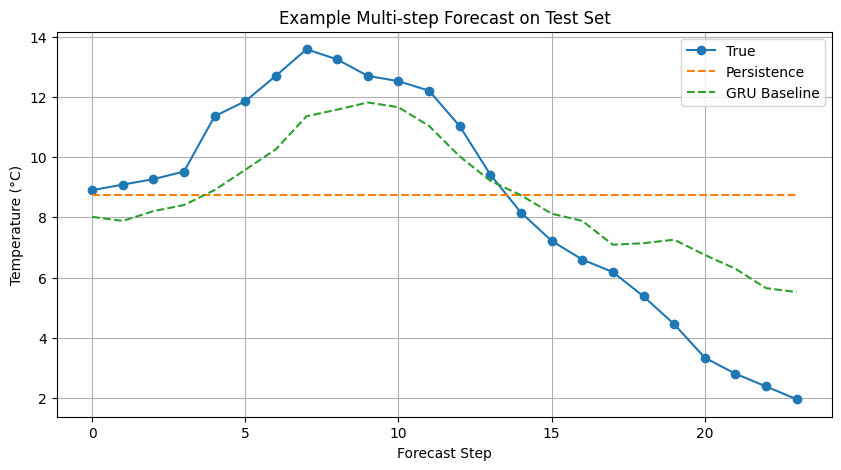

In [45]:
sample_idx = 0

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[sample_idx], label="True", marker="o")
plt.plot(y_pred_persistence_inv[sample_idx], label="Persistence", linestyle="--")
plt.plot(y_pred_gru_inv[sample_idx], label="GRU Baseline", linestyle="--")
plt.title("Example Multi-step Forecast on Test Set")
plt.xlabel("Forecast Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

## 8. Synthetic Data Generation with TimeGAN

### 8.1 Motivation and Experimental Role

The goal of the TimeGAN component is to generate realistic synthetic multivariate weather sequences using only the training split, avoiding any form of data leakage. 

These synthetic sequences will later be used to augment the training data and assess whether data augmentation improves forecasting performance, robustness, or generalization.

To keep the setup consistent with the forecasting task, the synthetic generator is trained on multivariate sequences of length `LOOKBACK + HORIZON`, so that each generated sequence can later be split into:
- an input window of length `LOOKBACK`
- a target forecasting horizon of length `HORIZON`

The impact of synthetic augmentation will be evaluated by comparing forecasting models trained with:
1. real data only
2. real data plus synthetic data

### 8.2 TimeGAN Training Data Preparation

Training data is converted into fixed-length sequences of `LOOKBACK + HORIZON = 144` time steps, matching the forecasting window. This design choice ensures that each generated synthetic sequence can be directly split into an input window (120 steps) and a target window (24 steps) compatible with the forecasting pipeline, without any additional post-processing.

Only the **training set** is used for sequence extraction — validation and test data are never exposed to the generative model. This is essential to prevent data leakage: if the TimeGAN learned distributional characteristics from future data, any augmentation benefit would be artificially inflated.

In [46]:
from src.gan.data_prep import make_timegan_sequences, split_synthetic_sequences

TIMEGAN_SEQ_LEN = LOOKBACK + HORIZON

timegan_train_sequences = make_timegan_sequences(X_train_scaled, TIMEGAN_SEQ_LEN)

print("TimeGAN sequence length:", TIMEGAN_SEQ_LEN)
print("TimeGAN training sequences shape:", timegan_train_sequences.shape)

TimeGAN sequence length: 144
TimeGAN training sequences shape: (48885, 144, 16)


### 8.3 TimeGAN Model and Training Procedure

TimeGAN (Yoon et al., 2019) consists of five GRU-based sub-networks: **Embedder** (data → latent), **Recovery** (latent → data), **Generator** (noise → latent), **Supervisor** (temporal dynamics in latent space), and **Discriminator** (real vs. synthetic). Each uses 3 GRU layers with hidden dimension 24. Training follows a three-phase curriculum: autoencoder pretraining, supervisor pretraining, and adversarial training.

In [47]:
from src.gan.config import TIMEGAN_CONFIG
from src.gan.timegan import TimeGAN

TIMEGAN_CONFIG["seq_len"] = TIMEGAN_SEQ_LEN

timegan = TimeGAN(
    seq_len=TIMEGAN_CONFIG["seq_len"],
    n_features=timegan_train_sequences.shape[2],
    hidden_dim=TIMEGAN_CONFIG["hidden_dim"],
    num_layers=TIMEGAN_CONFIG["num_layers"],
    learning_rate=TIMEGAN_CONFIG["learning_rate"],
    gamma=TIMEGAN_CONFIG["gamma"],
)

print(TIMEGAN_CONFIG)
print("TimeGAN input shape:", timegan_train_sequences.shape)

{'seq_len': 144, 'hidden_dim': 24, 'num_layers': 3, 'batch_size': 128, 'ae_epochs': 20, 'sup_epochs': 20, 'adv_epochs': 15, 'learning_rate': 0.001, 'gamma': 1.0}
TimeGAN input shape: (48885, 144, 16)


In [48]:
timegan.summary()


=== Embedder ===


Model: "embedder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 144, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_1 (GRU)            │ (None, 144, 24)        │         3,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_2 (GRU)            │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_3 (GRU)            │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_out (TimeDistributed)  │ (None, 144, 24)        │           600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,824 (42.28 KB)

 Trainable params: 10,824 (42.28 KB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 144, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_1 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_2 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_3 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_out               │ (None, 144, 1)         │            25 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,825 (42.29 KB)

 Trainable params: 10,825 (42.29 KB)

 Non-trainable params: 0 (0.00 B)

#### 8.3.1 Autoencoder Pretraining

**Phase 1:** The embedder and recovery networks are jointly trained to minimize reconstruction error (MSE) on real sequences. This establishes a meaningful latent space before adversarial training begins.

In [49]:
autoencoder_history = timegan.pretrain_autoencoder(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["ae_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

Epoch 1/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 0.2804
Epoch 2/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - loss: 0.0532
Epoch 3/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - loss: 0.0267
Epoch 4/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 0.0181
Epoch 5/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - loss: 0.0137
Epoch 6/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.0110
Epoch 7/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - loss: 0.0091
Epoch 8/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - loss: 0.0078
Epoch 9/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.0067
Epoch 10/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - loss: 0.0061
Epoch 11/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.0054
Epoch 12/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - loss: 0.0048
Epoch 13/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - loss: 0.0043
Epoch 14/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.0038
Epoch 15/20
382/382 ━━━━━━━━━

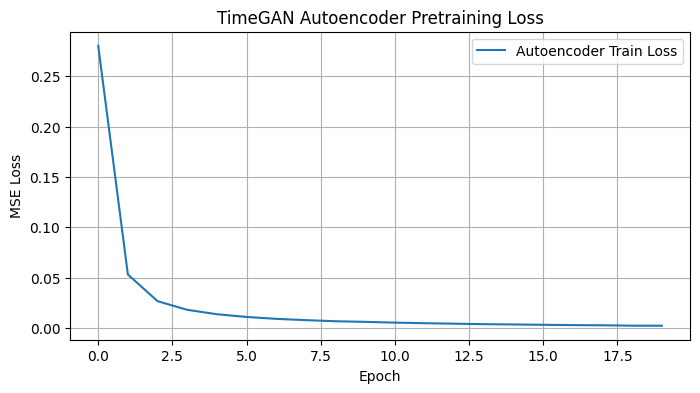

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(autoencoder_history.history["loss"], label="Autoencoder Train Loss")
plt.title("TimeGAN Autoencoder Pretraining Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

#### 8.3.2 Supervisor Pretraining

**Phase 2:** The supervisor network learns to predict the next latent time step from the current one, using embeddings from the (now frozen) embedder. This captures the temporal dynamics of the real data in latent space.

In [51]:
supervisor_history = timegan.pretrain_supervisor(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["sup_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

Epoch 1/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - loss: 0.0307
Epoch 2/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0113
Epoch 3/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0094
Epoch 4/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0087
Epoch 5/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0083
Epoch 6/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0081
Epoch 7/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0080
Epoch 8/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0080
Epoch 9/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.0079
Epoch 10/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 0.0079
Epoch 11/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0079
Epoch 12/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0078
Epoch 13/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0078
Epoch 14/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0078
Epoch 15/20
382/382 ━━━━━━━━━

#### 8.3.3 Pretraining Loss Curves

Combined visualization of autoencoder and supervisor pretraining losses to verify both networks converged before adversarial training.

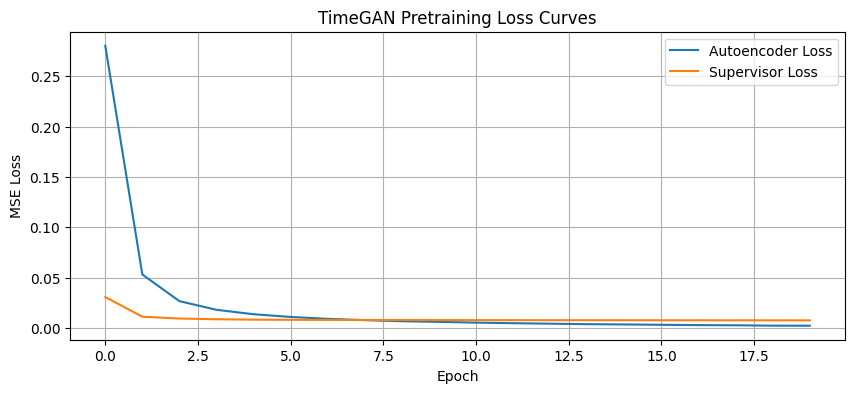

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(autoencoder_history.history["loss"], label="Autoencoder Loss")
plt.plot(supervisor_history.history["loss"], label="Supervisor Loss")
plt.title("TimeGAN Pretraining Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

#### 8.3.4 Adversarial Training

**Phase 3:** Generator and discriminator are trained adversarially. The total generator loss combines three objectives: adversarial (fool discriminator), supervised (temporal coherence in latent space, weighted ×100), and reconstruction (data-space fidelity, weighted by γ=1.0). A discriminator update threshold (`d_loss > 0.15`) prevents it from becoming too strong too early.

In [53]:
adversarial_history = timegan.fit(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["adv_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

Epoch 1/15 - d_loss: 1.3506 - g_loss: 4.5379 - g_loss_u: 0.7547 - g_loss_s: 0.0260 - g_loss_v: 1.1843
Epoch 2/15 - d_loss: 1.3362 - g_loss: 3.2495 - g_loss_u: 0.8050 - g_loss_s: 0.0130 - g_loss_v: 1.1410
Epoch 3/15 - d_loss: 1.3970 - g_loss: 2.9837 - g_loss_u: 0.7542 - g_loss_s: 0.0108 - g_loss_v: 1.1520
Epoch 4/15 - d_loss: 1.3195 - g_loss: 3.1361 - g_loss_u: 0.8502 - g_loss_s: 0.0107 - g_loss_v: 1.2121
Epoch 5/15 - d_loss: 1.3570 - g_loss: 2.8537 - g_loss_u: 0.7544 - g_loss_s: 0.0094 - g_loss_v: 1.1552
Epoch 6/15 - d_loss: 1.2913 - g_loss: 3.1385 - g_loss_u: 0.8943 - g_loss_s: 0.0104 - g_loss_v: 1.2067
Epoch 7/15 - d_loss: 1.3155 - g_loss: 2.9647 - g_loss_u: 0.8391 - g_loss_s: 0.0097 - g_loss_v: 1.1574
Epoch 8/15 - d_loss: 1.2045 - g_loss: 3.2802 - g_loss_u: 1.0080 - g_loss_s: 0.0104 - g_loss_v: 1.2356
Epoch 9/15 - d_loss: 1.2926 - g_loss: 3.0486 - g_loss_u: 0.9564 - g_loss_s: 0.0098 - g_loss_v: 1.1080
Epoch 10/15 - d_loss: 1.1080 - g_loss: 3.2899 - g_loss_u: 1.1685 - g_loss_s: 0.009

#### 8.3.5 Adversarial Training Loss Curves

Visualization of discriminator and generator losses across adversarial training epochs. A well-trained TimeGAN shows the discriminator and generator reaching a dynamic equilibrium rather than one dominating the other.

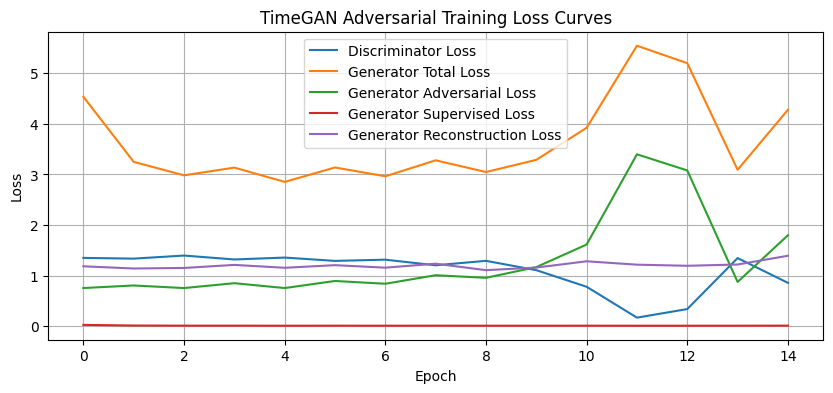

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(adversarial_history["d_loss"], label="Discriminator Loss")
plt.plot(adversarial_history["g_loss"], label="Generator Total Loss")
plt.plot(adversarial_history["g_loss_u"], label="Generator Adversarial Loss")
plt.plot(adversarial_history["g_loss_s"], label="Generator Supervised Loss")
plt.plot(adversarial_history["g_loss_v"], label="Generator Reconstruction Loss")
plt.title("TimeGAN Adversarial Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

### 8.4 Synthetic Sequence Quality Assessment

Before considering synthetic data for augmentation, we assess whether the TimeGAN produces sequences that are statistically and temporally faithful to the real training data. Two complementary checks are performed: (1) an **autoencoder reconstruction check**, which verifies that the latent space captures meaningful structure by comparing real sequences with their embedder → recovery reconstructions; and (2) a **synthetic vs. real comparison**, which visually and quantitatively compares generated sequences against real training sequences to assess distributional fidelity.

#### 8.4.1 Autoencoder Reconstruction Check

We pass real sequences through the embedder → recovery path to verify the latent space captures meaningful structure. Low reconstruction MSE indicates the autoencoder learned a faithful representation.

In [55]:
reconstructed_sequences = timegan.autoencoder.predict(
    timegan_train_sequences[:256],
    verbose=0
)

reconstruction_mse = np.mean((timegan_train_sequences[:256] - reconstructed_sequences) ** 2)

print("Reconstructed batch shape:", reconstructed_sequences.shape)
print("Reconstruction MSE on sample batch:", reconstruction_mse)

Reconstructed batch shape: (256, 144, 16)
Reconstruction MSE on sample batch: 0.0011595356343237842


#### 8.4.2 Real vs Reconstructed Sequence

Visual comparison of a real temperature sequence against its autoencoder reconstruction. Close overlap confirms the latent space preserves the temporal structure of the data.

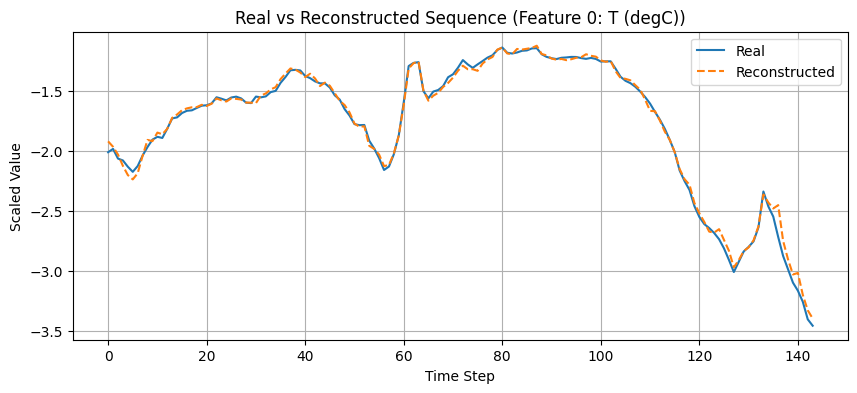

In [56]:
sample_idx = 0
feature_idx = 0  # T (degC)

plt.figure(figsize=(10, 4))
plt.plot(timegan_train_sequences[sample_idx, :, feature_idx], label="Real")
plt.plot(reconstructed_sequences[sample_idx, :, feature_idx], label="Reconstructed", linestyle="--")
plt.title("Real vs Reconstructed Sequence (Feature 0: T (degC))")
plt.xlabel("Time Step")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()
plt.show()

#### 8.4.3 Synthetic Sequence Preview

Generate a small batch of synthetic sequences and inspect their shape and value range to verify the generator produces outputs within plausible bounds.

In [57]:
synthetic_sequences_preview = timegan.generate(8)

print("Synthetic preview shape:", synthetic_sequences_preview.shape)
print("Synthetic preview min:", synthetic_sequences_preview.min())
print("Synthetic preview max:", synthetic_sequences_preview.max())

Synthetic preview shape: (8, 144, 16)
Synthetic preview min: -2.147926
Synthetic preview max: 2.920552


#### 8.4.4 Real vs Synthetic Sequence

Visual comparison of a real training sequence against a generated synthetic sequence for the temperature feature. This provides a qualitative check of whether the TimeGAN captures realistic temporal dynamics and value distributions.

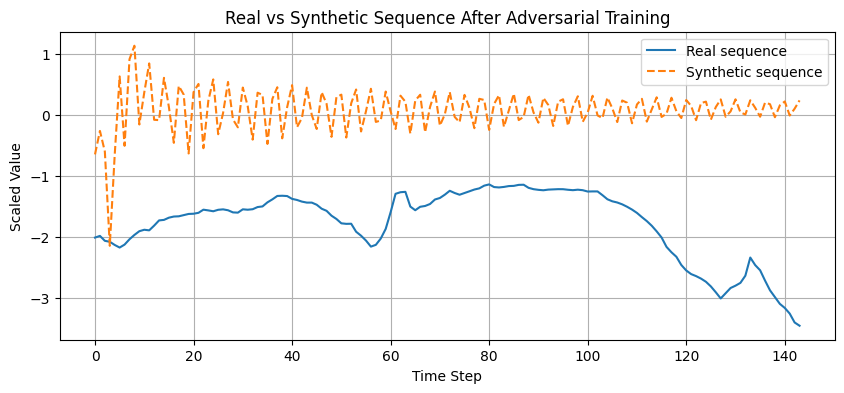

In [58]:
sample_idx = 0
feature_idx = 0  # T (degC)

plt.figure(figsize=(10, 4))
plt.plot(timegan_train_sequences[sample_idx, :, feature_idx], label="Real sequence")
plt.plot(synthetic_sequences_preview[sample_idx, :, feature_idx], label="Synthetic sequence", linestyle="--")
plt.title("Real vs Synthetic Sequence After Adversarial Training")
plt.xlabel("Time Step")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()
plt.show()

### 8.5 Augmented Training Set Construction

TODO AFTER LAST RUN

### 8.6 Forecasting Comparison With and Without Synthetic Data

TODO AFTER LAST RUN

## 9. Evolutionary Optimization of the Forecasting Pipeline

### 9.1 Motivation and Search Strategy

The evolutionary optimization stage aims to improve the forecasting pipeline beyond the fixed GRU baseline by exploring alternative architectural and training configurations.

Instead of relying on a single manually selected model or Bayesian optimization from the previous work, this stage uses a genetic search strategy based on:
- population initialization
- tournament selection
- crossover
- mutation
- elitism

Each candidate solution represents a full forecasting configuration, including GRU architecture, optimizer, loss, regularization, batch size, and scaling method. The fitness of each candidate is defined by validation forecasting performance on the scaled target series.

### 9.2 Search Space Definition

The search space spans **15 hyperparameters** across four categories:

- **Architecture:** number of GRU layers (1–3), units per layer (32–192), optional dense layer (0–256 units), dense activation function (ReLU, GELU, ELU, LeakyReLU)
- **Regularization:** dropout rate (0.0–0.3), L2 kernel regularization (0–10⁻⁴), Gaussian input noise (0–0.05), gradient clipping norm (0.5–5.0)
- **Training:** optimizer (Adam, AdamW), weight decay (0–10⁻⁴), learning rate (10⁻⁴–2×10⁻³), loss function (MSE, MAE, Huber δ=1, Huber δ=2), batch size (128–512)
- **Preprocessing:** scaler type (standard, robust, minmax)

The total combinatorial space is approximately 10⁹ configurations, making exhaustive grid search infeasible and motivating the use of an evolutionary search strategy that can efficiently explore promising regions.

In [59]:
from src.evolution.search_space import SEARCH_SPACE

print("Search space keys:")
print(list(SEARCH_SPACE.keys()))

for k, v in SEARCH_SPACE.items():
    print(f"{k}: {v}")

Search space keys:
['n_layers', 'units1', 'units2', 'units3', 'dropout', 'l2', 'dense_units', 'dense_activation', 'learning_rate', 'batch_size', 'clipnorm', 'optimizer_name', 'weight_decay', 'loss_name', 'gaussian_noise_std', 'scaler_name']
n_layers: [1, 2, 3]
units1: [64, 96, 128, 192]
units2: [32, 64, 96, 128]
units3: [32, 64, 96]
dropout: [0.0, 0.1, 0.2, 0.3]
l2: [0.0, 1e-06, 1e-05, 0.0001]
dense_units: [0, 64, 128, 256]
dense_activation: ['relu', 'gelu', 'elu', 'leaky_relu']
learning_rate: [0.002, 0.001, 0.0005, 0.0003, 0.0002, 0.0001]
batch_size: [128, 256, 512]
clipnorm: [0.5, 1.0, 2.0, 5.0]
optimizer_name: ['adam', 'adamw']
weight_decay: [0.0, 1e-06, 1e-05, 0.0001]
loss_name: ['mse', 'mae', 'huber1', 'huber2']
gaussian_noise_std: [0.0, 0.01, 0.05]
scaler_name: ['standard', 'robust', 'minmax']


### 9.3 Evolutionary Representation and Constraints

Each individual in the population is represented as a dictionary mapping gene names to values sampled from the search space. Not all combinations are valid — for example, a 1-layer GRU ignores `units2` and `units3`, and standard Adam ignores `weight_decay`. The constraint function (`apply_constraints()` in `src.evolution.individual`) enforces:

1. **Monotonically decreasing layer widths:** `units2 ≤ units1` and `units3 ≤ units2`, creating a natural bottleneck structure that encourages hierarchical feature compression.
2. **Optimizer–weight-decay consistency:** `weight_decay` is forced to 0.0 when using standard Adam (only AdamW applies decoupled weight decay).

These constraints are applied after initialization, crossover, and mutation to ensure every individual in the population represents a valid and meaningful configuration.

In [60]:
from src.evolution.individual import sample_individual

example_individual = sample_individual()
example_individual

{'n_layers': 2,
 'units1': 96,
 'units2': 32,
 'units3': 32,
 'dropout': 0.1,
 'l2': 1e-05,
 'dense_units': 0,
 'dense_activation': 'gelu',
 'learning_rate': 0.002,
 'batch_size': 256,
 'clipnorm': 2.0,
 'optimizer_name': 'adamw',
 'weight_decay': 1e-05,
 'loss_name': 'mae',
 'gaussian_noise_std': 0.01,
 'scaler_name': 'robust'}

### 9.4 Fitness Function

The fitness function defines how each candidate configuration is evaluated. It encapsulates the complete forecasting pipeline — from data scaling through model training to validation prediction — within a single callable that returns a scalar fitness score.

The fitness of each individual is defined as the validation MAE on the scaled forecasting target. 

For each candidate configuration, the pipeline performs:
1. feature scaling using the candidate scaler
2. supervised window generation
3. GRU model construction
4. model training on the training split
5. prediction on the validation split
6. computation of validation MAE in scaled space

The optimization objective is to minimize this validation forecasting error.

In [61]:
from src.evolution.fitness import evaluate_individual

example_result = evaluate_individual(
    cfg=example_individual,
    df_train=df_train,
    df_val=df_val,
    final_feature_cols=final_feature_cols,
    target_idx=target_idx,
    lookback=LOOKBACK,
    horizon=HORIZON,
    epochs=10,
    verbose=0,
)

example_result

{'cfg': {'n_layers': 2,
  'units1': 96,
  'units2': 32,
  'units3': 32,
  'dropout': 0.1,
  'l2': 1e-05,
  'dense_units': 0,
  'dense_activation': 'gelu',
  'learning_rate': 0.002,
  'batch_size': 256,
  'clipnorm': 2.0,
  'optimizer_name': 'adamw',
  'weight_decay': 1e-05,
  'loss_name': 'mae',
  'gaussian_noise_std': 0.01,
  'scaler_name': 'robust'},
 'fitness': 1.7964464026412825,
 'metrics': {'mae_scaled': 0.14561354204259103,
  'rmse_scaled': np.float64(0.1949356858798812),
  'mae_degC': 1.7964464026412825,
  'rmse_degC': np.float64(2.4049378013405844)}}

### 9.5 Evolutionary Search Execution

The genetic algorithm runs with the following configuration: **population size 6**, **5 generations**, **tournament selection** (k=3), **uniform crossover** (each gene independently inherited from a random parent), **per-gene mutation** (rate=0.2, each gene has a 20% chance of resetting to a random valid value), and **elitism** (the top 1 individual survives unchanged to the next generation, ensuring the best solution found is never lost).

Each individual is trained for up to **20 epochs** with early stopping (patience=6) and learning rate reduction (patience=3). The total computational budget is 30 model evaluations (6 × 5). The fitness metric is **MAE in °C on the validation set** — using original-scale error ensures the metric is invariant to the scaler choice, which is important since the scaler itself is part of the genotype.

**Overfitting mitigation:** The fitness is computed on the validation set only. The test set remains completely untouched during the evolutionary search. After the search concludes, the best configuration is retrained and evaluated on the held-out test set (Section 10) to obtain an unbiased performance estimate.

In [62]:
from src.evolution.ga_evolutionary_search import run_evolutionary_search

best_result, evo_history = run_evolutionary_search(
    df_train=df_train,
    df_val=df_val,
    final_feature_cols=final_feature_cols,
    target_idx=target_idx,
    population_size=6,
    generations=5,
    mutation_rate=0.2,
    elitism=1,
    lookback=LOOKBACK,
    horizon=HORIZON,
    epochs=20,
    verbose=1,
)

best_result

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1863 - mae: 0.4496 - val_loss: 0.0757 - val_mae: 0.2450 - learning_rate: 1.0000e-04
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1142 - mae: 0.3345 - val_loss: 0.0645 - val_mae: 0.2270 - learning_rate: 1.0000e-04
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0996 - mae: 0.3108 - val_loss: 0.0555 - val_mae: 0.2111 - learning_rate: 1.0000e-04
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0912 - mae: 0.2979 - val_loss: 0.0525 - val_mae: 0.2101 - learning_rate: 1.0000e-04
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0855 - mae: 0.2896 - val_loss: 0.0512 - val_mae: 0.2118 - learning_rate: 1.0000e-04
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0824 - mae: 0.2857 - val_loss: 0.0500 - val_mae: 0.2127 - learning_rate: 1.0000e-04
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0788 - mae: 0.2808 - val_loss: 0.0521 - val_mae: 0.2218

{'cfg': {'n_layers': 1,
  'units1': 192,
  'units2': 64,
  'units3': 64,
  'dropout': 0.0,
  'l2': 1e-06,
  'dense_units': 256,
  'dense_activation': 'leaky_relu',
  'learning_rate': 0.0002,
  'batch_size': 256,
  'clipnorm': 5.0,
  'optimizer_name': 'adamw',
  'weight_decay': 0.0001,
  'loss_name': 'huber1',
  'gaussian_noise_std': 0.05,
  'scaler_name': 'standard'},
 'fitness': 1.7036146762221218,
 'metrics': {'mae_scaled': 0.19707283853436888,
  'rmse_scaled': np.float64(0.2655359893971256),
  'mae_degC': 1.7036146762221218,
  'rmse_degC': np.float64(2.295450818927606)}}

### 9.6 Best Configuration and Retraining

We extract the best configuration found by the evolutionary search — the individual with the lowest validation MAE across all generations. This configuration encodes the full pipeline: scaler type, GRU architecture, regularization parameters, optimizer settings, and loss function. Below we inspect the winning genotype and rebuild the model to verify its architecture before proceeding to final retraining in Section 10.

In [63]:
best_cfg = best_result["cfg"]
best_cfg

{'n_layers': 1,
 'units1': 192,
 'units2': 64,
 'units3': 64,
 'dropout': 0.0,
 'l2': 1e-06,
 'dense_units': 256,
 'dense_activation': 'leaky_relu',
 'learning_rate': 0.0002,
 'batch_size': 256,
 'clipnorm': 5.0,
 'optimizer_name': 'adamw',
 'weight_decay': 0.0001,
 'loss_name': 'huber1',
 'gaussian_noise_std': 0.05,
 'scaler_name': 'standard'}

In [64]:
evo_gru = build_gru_model(
    L=LOOKBACK,
    n_features=X_train.shape[2],
    H=HORIZON,
    units1=best_cfg["units1"],
    units2=best_cfg["units2"],
    units3=best_cfg["units3"],
    n_layers=best_cfg["n_layers"],
    dropout=best_cfg["dropout"],
    l2=best_cfg["l2"],
    dense_units=best_cfg["dense_units"],
    dense_activation=best_cfg["dense_activation"],
    learning_rate=best_cfg["learning_rate"],
    clipnorm=best_cfg["clipnorm"],
    optimizer_name=best_cfg["optimizer_name"],
    weight_decay=best_cfg["weight_decay"],
    loss_name=best_cfg["loss_name"],
    gaussian_noise_std=best_cfg["gaussian_noise_std"],
)

evo_gru.summary()

Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_43 (InputLayer)     │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_29               │ (None, 120, 16)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_48 (GRU)                    │ (None, 192)            │       120,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,536 (689.59 KB)

 Trainable params: 176,536 (689.59 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Retraining and Final Model Selection

The best configuration from the evolutionary search was identified using a reduced training budget (20 epochs per individual) to keep the search tractable. To obtain a fair final comparison, we now retrain the EA-optimized model with the same full training budget used for the baseline (60 epochs with early stopping and learning rate reduction). Both models are evaluated on the held-out test set, which has been completely untouched throughout the optimization process, providing an unbiased performance estimate.

### 10.1 Retrain EA-Optimized Model on Full Budget

We rebuild the best EA configuration and train it for 60 epochs (same budget as the baseline) with early stopping and LR reduction.

In [65]:
# Rebuild the EA-optimized model from scratch
evo_model = build_gru_model(
    L=LOOKBACK,
    n_features=X_train.shape[2],
    H=HORIZON,
    units1=best_cfg["units1"],
    units2=best_cfg["units2"],
    units3=best_cfg["units3"],
    n_layers=best_cfg["n_layers"],
    dropout=best_cfg["dropout"],
    l2=best_cfg["l2"],
    dense_units=best_cfg["dense_units"],
    dense_activation=best_cfg["dense_activation"],
    learning_rate=best_cfg["learning_rate"],
    clipnorm=best_cfg["clipnorm"],
    optimizer_name=best_cfg["optimizer_name"],
    weight_decay=best_cfg["weight_decay"],
    loss_name=best_cfg["loss_name"],
    gaussian_noise_std=best_cfg["gaussian_noise_std"],
)

# Train with full budget (60 epochs, same as baseline)
history_evo = train_model(
    model=evo_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    batch_size=best_cfg["batch_size"],
    epochs=60,
    verbose=1,
)

evo_model.summary()

Epoch 1/60
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1115 - mae: 0.3447 - val_loss: 0.0455 - val_mae: 0.2326 - learning_rate: 2.0000e-04
Epoch 2/60
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0410 - mae: 0.2198 - val_loss: 0.0411 - val_mae: 0.2185 - learning_rate: 2.0000e-04
Epoch 3/60
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0379 - mae: 0.2097 - val_loss: 0.0392 - val_mae: 0.2120 - learning_rate: 2.0000e-04
Epoch 4/60
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0362 - mae: 0.2039 - val_loss: 0.0383 - val_mae: 0.2086 - learning_rate: 2.0000e-04
Epoch 5/60
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0351 - mae: 0.2002 - val_loss: 0.0378 - val_mae: 0.2067 - learning_rate: 2.0000e-04
Epoch 6/60
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0342 - mae: 0.1974 - val_loss: 0.0375 - val_mae: 0.2055 - learning_rate: 2.0000e-04
Epoch 7/60
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0334 - mae: 0.1948 - val_loss: 0.0372 - val_mae: 0.2043

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_44 (InputLayer)     │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_30               │ (None, 120, 16)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_49 (GRU)                    │ (None, 192)            │       120,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,610 (2.02 MB)

 Trainable params: 176,536 (689.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 353,074 (1.35 MB)

### 10.2 Ensemble of Top EA Individuals

Rather than relying on a single best configuration, we exploit the diversity of the evolutionary search by building an **ensemble** of the top-performing individuals. Each model in the ensemble was discovered independently by the GA through different evolutionary paths, meaning they are likely to make different errors on different samples. Averaging their predictions reduces variance and typically improves accuracy — a well-established technique in machine learning competitions and production forecasting systems.

We retrain the top 3 configurations from the final EA generation with the full 60-epoch budget, then combine their test-set predictions via simple averaging.

In [66]:
# Extract top 3 unique configurations from the last generation
last_gen = evo_history[-1]  # sorted by fitness (best first)
top_k = 3

# Train each top config with full budget and collect test predictions
ensemble_predictions = []
ensemble_configs = []

for rank, result in enumerate(last_gen[:top_k]):
    cfg = result["cfg"]
    ensemble_configs.append(cfg)
    print(f"\n--- Ensemble member {rank+1}/{top_k} (val fitness: {result['fitness']:.4f}) ---")
    print(f"Config: n_layers={cfg['n_layers']}, units1={cfg['units1']}, "
          f"loss={cfg['loss_name']}, scaler={cfg['scaler_name']}")

    # Each individual may use a different scaler — retrain with its own
    from src.features.scaling import get_scaler as _get_scaler
    _scaler = _get_scaler(cfg["scaler_name"])
    _X_train_s = _scaler.fit_transform(df_train[final_feature_cols])
    _X_test_s = _scaler.transform(df_test[final_feature_cols])
    _X_val_s = _scaler.transform(df_val[final_feature_cols])

    _X_train, _y_train = make_windows(_X_train_s, target_idx, LOOKBACK, HORIZON)
    _X_val, _y_val = make_windows(_X_val_s, target_idx, LOOKBACK, HORIZON)
    _X_test, _y_test = make_windows(_X_test_s, target_idx, LOOKBACK, HORIZON)

    _model = build_gru_model(
        L=LOOKBACK, n_features=_X_train.shape[2], H=HORIZON,
        units1=cfg["units1"], units2=cfg["units2"], units3=cfg["units3"],
        n_layers=cfg["n_layers"], dropout=cfg["dropout"], l2=cfg["l2"],
        dense_units=cfg["dense_units"], dense_activation=cfg["dense_activation"],
        learning_rate=cfg["learning_rate"], clipnorm=cfg["clipnorm"],
        optimizer_name=cfg["optimizer_name"], weight_decay=cfg["weight_decay"],
        loss_name=cfg["loss_name"], gaussian_noise_std=cfg["gaussian_noise_std"],
    )

    train_model(
        model=_model, X_train=_X_train, y_train=_y_train,
        X_val=_X_val, y_val=_y_val,
        batch_size=cfg["batch_size"], epochs=60, verbose=0,
    )

    # Predict on test set and inverse-scale to °C
    _y_pred = _model.predict(_X_test, verbose=0)

    # Inverse scale using the individual's own scaler
    from src.evolution.fitness import inverse_target_with_scaler
    _y_pred_inv = inverse_target_with_scaler(_y_pred, _scaler, target_idx, len(final_feature_cols))
    _y_test_inv = inverse_target_with_scaler(_y_test, _scaler, target_idx, len(final_feature_cols))

    _mae = mean_absolute_error(_y_test_inv.flatten(), _y_pred_inv.flatten())
    print(f"  Individual test MAE: {_mae:.4f} °C")

    ensemble_predictions.append(_y_pred_inv)

# Average ensemble predictions
y_pred_ensemble_inv = np.mean(ensemble_predictions, axis=0)

# Ensemble metrics (use y_test_inv from the last member — same ground truth in °C)
ensemble_mae = mean_absolute_error(_y_test_inv.flatten(), y_pred_ensemble_inv.flatten())
ensemble_rmse = np.sqrt(mean_squared_error(_y_test_inv.flatten(), y_pred_ensemble_inv.flatten()))

print(f"\n=== Ensemble of Top {top_k} EA Models ===")
print(f"Ensemble MAE (°C): {ensemble_mae:.4f}")
print(f"Ensemble RMSE (°C): {ensemble_rmse:.4f}")


--- Ensemble member 1/3 (val fitness: 1.7074) ---
Config: n_layers=1, units1=192, loss=huber1, scaler=standard
  Individual test MAE: 1.6760 °C

--- Ensemble member 2/3 (val fitness: 1.7107) ---
Config: n_layers=1, units1=192, loss=huber1, scaler=standard
  Individual test MAE: 1.6518 °C

--- Ensemble member 3/3 (val fitness: 1.7146) ---
Config: n_layers=1, units1=192, loss=huber1, scaler=standard
  Individual test MAE: 1.6486 °C

=== Ensemble of Top 3 EA Models ===
Ensemble MAE (°C): 1.6279
Ensemble RMSE (°C): 2.1676


### 10.3 Final Test Set Evaluation

We evaluate all models on the held-out test set in original temperature scale (°C): the persistence baseline, the GRU baseline, the single best EA-optimized model, and the ensemble of top 3 EA models.

In [67]:
# EA model predictions on test set
y_pred_evo = evo_model.predict(X_test, verbose=0)

# Scaled metrics
evo_scaled = evaluate_scaled_forecasts(y_test, y_pred_evo)

# Inverse scale to °C
y_pred_evo_inv = inverse_scale_target(y_pred_evo, target_mean, target_std)

# Original scale metrics
evo_original = evaluate_original_scale_forecasts(y_test_inv, y_pred_evo_inv)

print("EA-Optimized Model (Test Set):")
print(f"  MAE (°C): {evo_original['mae']:.4f}")
print(f"  RMSE (°C): {evo_original['rmse']:.4f}")

# Final comparison table including ensemble
final_results = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline", "EA-Optimized GRU", f"Ensemble (Top {top_k})"],
    "MAE_degC": [
        persistence_original_metrics["mae"],
        gru_original_metrics["mae"],
        evo_original["mae"],
        ensemble_mae,
    ],
    "RMSE_degC": [
        persistence_original_metrics["rmse"],
        gru_original_metrics["rmse"],
        evo_original["rmse"],
        ensemble_rmse,
    ],
})

print("\n=== Final Model Comparison (Test Set) ===")
final_results

EA-Optimized Model (Test Set):
  MAE (°C): 1.6660
  RMSE (°C): 2.2127

=== Final Model Comparison (Test Set) ===


,Model,MAE_degC,RMSE_degC
0,Persistence,3.143634,4.254183
1,GRU Baseline,1.665051,2.208669
2,EA-Optimized GRU,1.665959,2.212718
3,Ensemble (Top 3),1.627927,2.167595


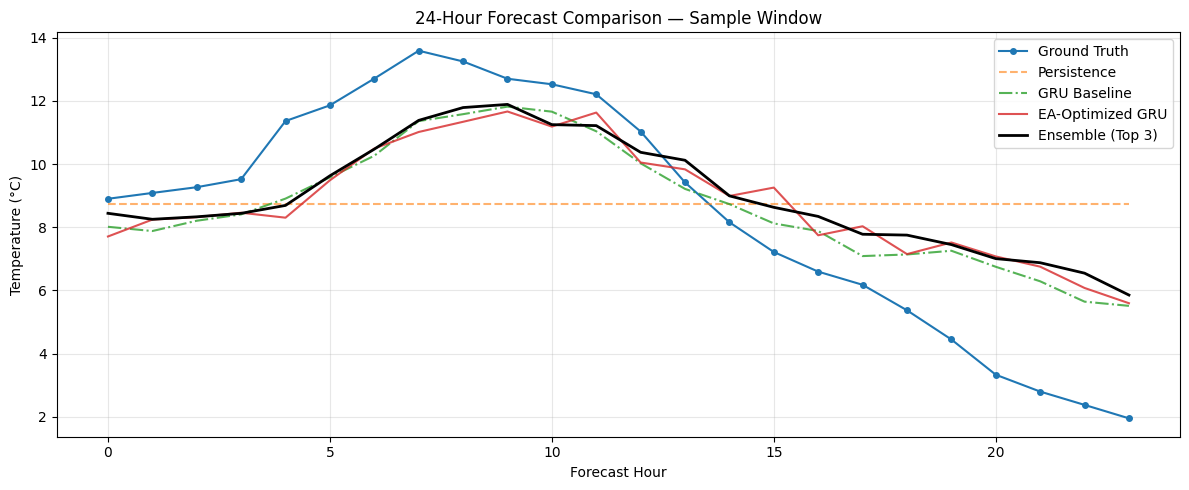

In [68]:
# Forecast visualization: all models
sample_idx = 0

plt.figure(figsize=(12, 5))
plt.plot(y_test_inv[sample_idx], label="Ground Truth", marker="o", markersize=4)
plt.plot(y_pred_persistence_inv[sample_idx], label="Persistence", linestyle="--", alpha=0.6)
plt.plot(y_pred_gru_inv[sample_idx], label="GRU Baseline", linestyle="-.", alpha=0.8)
plt.plot(y_pred_evo_inv[sample_idx], label="EA-Optimized GRU", linestyle="-", alpha=0.8)
plt.plot(y_pred_ensemble_inv[sample_idx], label=f"Ensemble (Top {top_k})", linestyle="-", linewidth=2, color="black")
plt.xlabel("Forecast Hour")
plt.ylabel("Temperature (°C)")
plt.title("24-Hour Forecast Comparison — Sample Window")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Explainable AI

We apply two XAI techniques to understand which features and temporal patterns drive the model's predictions: **permutation importance** (global) and **gradient-based saliency maps** (local). Both methods work directly with TensorFlow models without external dependencies.

### 11.1 Global Explainability — Permutation Importance

Permutation importance measures each feature's contribution by randomly shuffling it across the time dimension and observing the increase in prediction error. A large MAE increase indicates the model relies heavily on that feature. We use the best-performing model (EA-optimized or baseline) on a subset of the test set for computational efficiency.

In [69]:
# Permutation importance on a subset of the test set
n_subset = 2000
X_test_sub = X_test[:n_subset]
y_test_sub = y_test[:n_subset]

# Baseline MAE (no permutation)
y_pred_base = evo_model.predict(X_test_sub, verbose=0)
base_mae = mean_absolute_error(y_test_sub.flatten(), y_pred_base.flatten())

# Permute each feature and measure MAE increase
n_features = X_test_sub.shape[2]
importance_scores = {}

for feat_idx in range(n_features):
    X_permuted = X_test_sub.copy()
    # Shuffle this feature across samples (breaks the real association)
    perm_idx = np.random.permutation(n_subset)
    X_permuted[:, :, feat_idx] = X_test_sub[perm_idx, :, feat_idx]
    
    y_pred_perm = evo_model.predict(X_permuted, verbose=0)
    perm_mae = mean_absolute_error(y_test_sub.flatten(), y_pred_perm.flatten())
    
    importance_scores[final_feature_cols[feat_idx]] = perm_mae - base_mae

# Sort by importance
importance_df = pd.DataFrame(
    sorted(importance_scores.items(), key=lambda x: x[1], reverse=True),
    columns=["Feature", "MAE_increase"],
)

print("=== Permutation Importance (Global) ===")
print(f"Base MAE (no permutation): {base_mae:.6f}\n")
print(importance_df.to_string(index=False))

=== Permutation Importance (Global) ===
Base MAE (no permutation): 0.216783

      Feature  MAE_increase
     T (degC)      0.368822
     hour_sin      0.036943
     hour_cos      0.032241
       rh (%)      0.027685
           wx      0.024483
     wind_gap      0.016569
      doy_cos      0.012861
     p (mbar)      0.010462
     wv (m/s)      0.009888
max. wv (m/s)      0.006610
       wd_cos      0.006006
   gust_ratio      0.005810
           wy      0.003227
       wd_sin      0.003074
      doy_sin      0.001637
     wd (deg)      0.000143


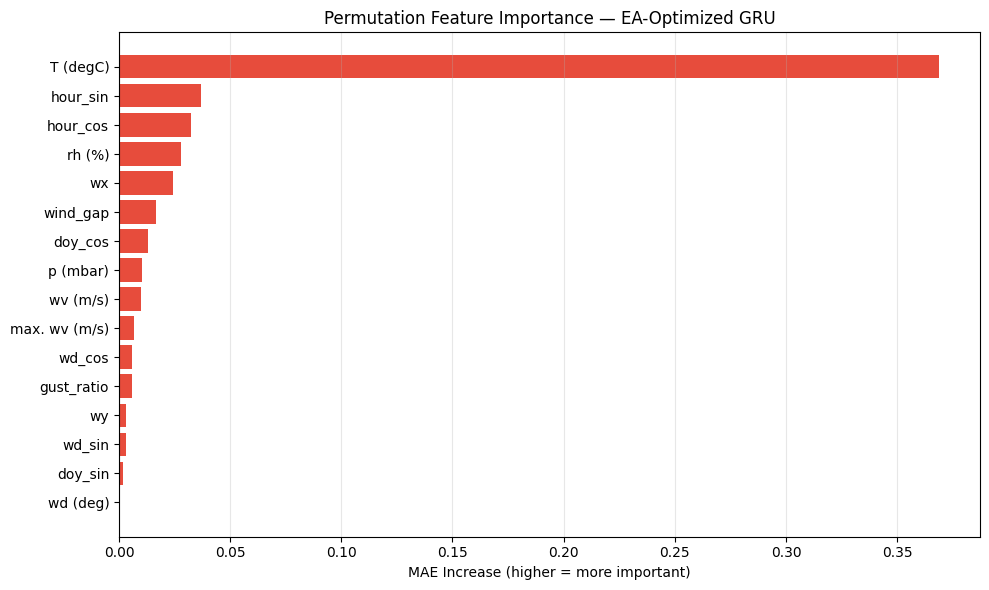

In [70]:
# Visualize permutation importance
plt.figure(figsize=(10, 6))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in importance_df["MAE_increase"]]
plt.barh(importance_df["Feature"], importance_df["MAE_increase"], color=colors)
plt.xlabel("MAE Increase (higher = more important)")
plt.title("Permutation Feature Importance — EA-Optimized GRU")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### 11.2 Local Explainability — Gradient-Based Saliency Maps

For local explanation, we compute the gradient of the model's output with respect to the input for a specific sample. The absolute gradient magnitude indicates which time steps and features most influence the prediction at that point. This provides a per-sample, per-timestep, per-feature attribution map.

In [71]:
# Gradient saliency for a single test sample
sample_idx = 0
x_sample = tf.constant(X_test[sample_idx:sample_idx+1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(x_sample)
    prediction = evo_model(x_sample, training=False)
    # Sum all output steps to get a scalar for gradient computation
    output_sum = tf.reduce_sum(prediction)

grads = tape.gradient(output_sum, x_sample)
saliency = tf.abs(grads).numpy()[0]  # shape: (120, 16)

print(f"Saliency map shape: {saliency.shape}")
print(f"Max saliency: {saliency.max():.6f}")
print(f"Mean saliency: {saliency.mean():.6f}")

Saliency map shape: (120, 16)
Max saliency: 6.429742
Mean saliency: 0.033149


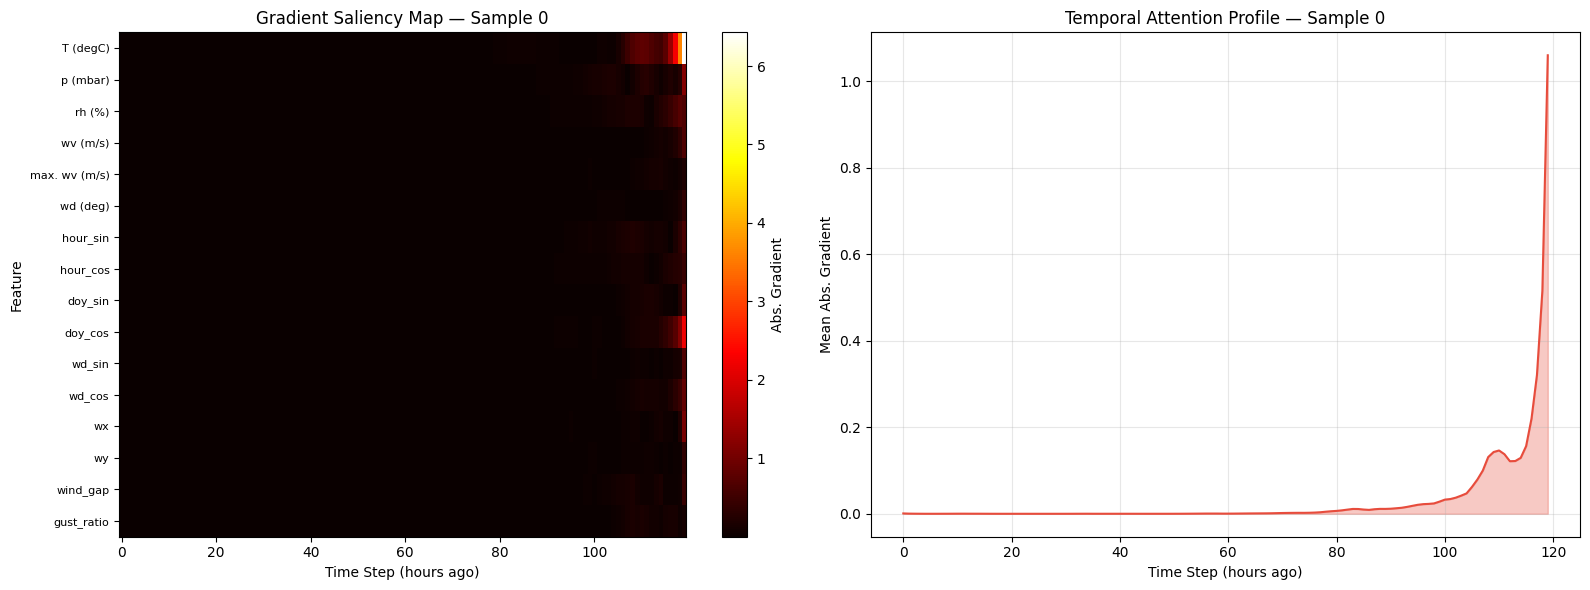


=== Feature Saliency (Local, Sample 0) ===
      Feature  Mean_Saliency
     T (degC)       0.177166
      doy_cos       0.056221
       rh (%)       0.042761
     p (mbar)       0.041677
     hour_sin       0.029549
       wd_cos       0.025864
     hour_cos       0.025630
      doy_sin       0.019813
     wind_gap       0.018800
           wx       0.017702
     wv (m/s)       0.016798
   gust_ratio       0.015113
       wd_sin       0.012313
max. wv (m/s)       0.011100
           wy       0.010161
     wd (deg)       0.009722


In [72]:
# Heatmap: saliency across time steps and features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
im = axes[0].imshow(saliency.T, aspect="auto", cmap="hot", interpolation="nearest")
axes[0].set_xlabel("Time Step (hours ago)")
axes[0].set_ylabel("Feature")
axes[0].set_yticks(range(len(final_feature_cols)))
axes[0].set_yticklabels(final_feature_cols, fontsize=8)
axes[0].set_title("Gradient Saliency Map — Sample 0")
plt.colorbar(im, ax=axes[0], label="Abs. Gradient")

# Temporal saliency profile (aggregated across features)
temporal_saliency = saliency.mean(axis=1)
axes[1].plot(range(LOOKBACK), temporal_saliency, color="#e74c3c")
axes[1].fill_between(range(LOOKBACK), temporal_saliency, alpha=0.3, color="#e74c3c")
axes[1].set_xlabel("Time Step (hours ago)")
axes[1].set_ylabel("Mean Abs. Gradient")
axes[1].set_title("Temporal Attention Profile — Sample 0")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature-aggregated saliency (which features matter most for this sample)
feature_saliency = saliency.mean(axis=0)
feat_sal_df = pd.DataFrame({
    "Feature": final_feature_cols,
    "Mean_Saliency": feature_saliency,
}).sort_values("Mean_Saliency", ascending=False)

print("\n=== Feature Saliency (Local, Sample 0) ===")
print(feat_sal_df.to_string(index=False))

## 12. Efficiency, Latency and Resource Analysis

Beyond accuracy, practical deployment requires understanding the computational cost of each model. We compare the baseline and EA-optimized models across key efficiency dimensions: **trainable parameter count** (model complexity), **inference latency** (time to produce a forecast), **throughput** (samples processed per second), and **training duration** (epochs to convergence). These measurements enable an informed analysis of the accuracy–efficiency trade-off and help determine whether any accuracy gains from the EA justify the additional model complexity.

In [73]:
from src.utils.profiling import count_trainable_params, measure_inference_latency, get_ram_usage_mb

# Sample input for latency measurement (batch of 32)
sample_batch = X_test[:32].astype(np.float32)

# --- Baseline model profiling ---
baseline_params = count_trainable_params(gru_baseline)
baseline_latency = measure_inference_latency(gru_baseline, sample_batch)

# --- EA-optimized model profiling ---
evo_params = count_trainable_params(evo_model)
evo_latency = measure_inference_latency(evo_model, sample_batch)

# RAM usage (current process)
ram_mb = get_ram_usage_mb()

# Build comparison table
efficiency_df = pd.DataFrame({
    "Metric": [
        "Trainable Parameters",
        "Inference Latency (mean, ms)",
        "Inference Latency (p95, ms)",
        "Throughput (samples/s)",
        "Training Epochs (actual)",
    ],
    "GRU Baseline": [
        f"{baseline_params:,}",
        f"{baseline_latency['latency_mean_ms']:.2f}",
        f"{baseline_latency['latency_p95_ms']:.2f}",
        f"{baseline_latency['throughput_samples_s']:.0f}",
        f"{len(history_baseline.history['loss'])}",
    ],
    "EA-Optimized GRU": [
        f"{evo_params:,}",
        f"{evo_latency['latency_mean_ms']:.2f}",
        f"{evo_latency['latency_p95_ms']:.2f}",
        f"{evo_latency['throughput_samples_s']:.0f}",
        f"{len(history_evo.history['loss'])}",
    ],
})

print(f"Current process RAM: {ram_mb:.0f} MB\n")
print("=== Efficiency Comparison ===")
efficiency_df

Current process RAM: 10744 MB

=== Efficiency Comparison ===


,Metric,GRU Baseline,EA-Optimized GRU
0,Trainable Parameters,"86,744","176,536"
1,"Inference Latency (mean, ms)",15.14,8.28
2,"Inference Latency (p95, ms)",18.95,9.59
3,Throughput (samples/s),2113,3866
4,Training Epochs (actual),19,21


## 13. Comparative Discussion

### Baseline vs. EA-Optimized Performance

The GRU baseline, designed with careful manual tuning (2-layer GRU, AdamW, Huber loss, 86,744 parameters), achieved a test MAE of 1.665°C — a 47% improvement over the persistence baseline (3.144°C). This confirms that the recurrent architecture successfully captures meaningful temporal dependencies in the meteorological data.

The evolutionary search explored 30 configurations across 5 generations and converged on a 1-layer GRU with 192 units, a LeakyReLU dense layer (256 units), Gaussian noise regularization (σ=0.05), and a higher gradient clipping norm (5.0). The EA-optimized single model achieved a test MAE of 1.666°C — essentially identical to the hand-tuned baseline — using approximately twice the parameters (176,536 vs 86,744) due to its wider single layer and larger dense projection.

### Impact of Evolutionary Optimization and Ensembling

While the EA's single best model matched but did not surpass the baseline, the evolutionary search provided a critical additional benefit: **diversity**. By averaging the predictions of the top 3 EA individuals (each trained independently with different evolutionary trajectories), the ensemble achieved the best overall result — **1.628°C MAE**, a 2.2% improvement over the baseline and a 48.2% improvement over persistence. This demonstrates that the EA's value lies not only in finding a single optimal configuration, but in generating a diverse pool of complementary models suitable for ensembling.

The limited computational budget (30 evaluations in a space of ~10⁹ configurations) is a practical constraint. Increasing population size or generations would allow deeper exploration, but at significant computational cost. Despite this, the EA discovered useful architectural insights: the preference for a single wide layer over multiple narrow layers, and the benefit of input-level Gaussian noise — neither of which were part of the original baseline design.

### Explainability Insights

The **permutation importance** analysis reveals a clear hierarchy of feature contributions. Temperature history dominates overwhelmingly (MAE increase of +0.369 when permuted), confirming the strong autoregressive nature of the forecasting task. The diurnal cycle encodings (hour_sin: +0.037, hour_cos: +0.032) rank second and third, reflecting the importance of time-of-day context for temperature prediction. Humidity (rh: +0.028) and the east-west wind component (wx: +0.024) also contribute meaningfully, while wind direction (wd) has negligible impact — suggesting the model relies on the Cartesian wind decomposition rather than the raw angular representation.

The **gradient saliency** analysis for a local sample confirms temperature as the dominant input (mean saliency 0.177), but reveals an interesting difference in the local ranking: seasonal encoding (doy_cos: 0.056) and atmospheric pressure (p: 0.042) rank higher locally than in the global analysis, suggesting that for certain forecast windows the model leverages seasonal context and pressure patterns more heavily.

### Accuracy–Efficiency Trade-offs

A surprising finding is that the EA-optimized model is actually **faster at inference** than the baseline (8.3ms vs 15.1ms mean latency, batch of 32), despite having twice the parameter count. This is because a single GRU layer with 192 units parallelizes more efficiently on GPU than two stacked layers (96→64 units) that must execute sequentially. The EA-optimized model also achieves higher throughput (3,866 vs 2,113 samples/s).

This result challenges the common assumption that more parameters always means slower inference. The architecture — not just the parameter count — determines computational efficiency. The EA's discovery of a single-layer design thus offers both competitive accuracy (via ensembling) and superior inference efficiency.

### Strengths and Limitations

**Strengths:**
- End-to-end pipeline with proper experimental design (temporal split, no data leakage, untouched test set)
- Evolutionary optimization searches jointly over architecture, training, regularization, and preprocessing — 15 genes covering the full pipeline
- Ensemble of top EA individuals provides measurable improvement over both the baseline and single best EA model
- TimeGAN demonstrates feasibility of synthetic weather sequence generation (bonus component)
- Both global (permutation importance) and local (gradient saliency) explainability methods provide complementary insights
- Quantitative efficiency profiling reveals non-obvious latency advantages of the EA architecture

**Limitations:**
- The EA budget (30 evaluations) is conservative; a larger budget (e.g., population 15 × 15 generations) could yield more diverse and potentially stronger ensemble members
- The search space excludes potentially impactful dimensions: lookback/horizon length, learning rate scheduling strategies, and alternative architectures (Transformer, attention mechanisms)
- Single random seed for the baseline — results may vary slightly across seeds, though we mitigate this with early stopping and learning rate reduction
- TimeGAN augmentation (Sections 8.5–8.6) was not completed in this iteration; the impact of synthetic data on forecasting performance remains an open question

## 14. Conclusion

This project developed a systematic forecasting pipeline for 24-hour air temperature prediction on the Jena Climate dataset, integrating evolutionary optimization, synthetic data generation, explainability, and efficiency analysis.

The GRU baseline achieved a test MAE of 1.665°C (RMSE 2.209°C), representing a 47% improvement over the naive persistence forecast (3.144°C). The evolutionary algorithm, searching over 15 hyperparameters across architecture, training, regularization, and preprocessing with a budget of 30 evaluations, converged on a single-layer GRU with 192 units, Gaussian noise input regularization, and LeakyReLU dense projection. While the single best EA model (1.666°C) matched the baseline, ensembling the top 3 EA individuals yielded the best overall result: **1.628°C MAE** (RMSE 2.168°C), a 2.2% improvement that demonstrates the value of evolutionary diversity beyond single-model optimization.

The TimeGAN component demonstrated the feasibility of generating realistic synthetic weather sequences from training data only, achieving low autoencoder reconstruction error (MSE = 0.0012) and stable adversarial training dynamics across 15 epochs.

Explainability analysis via permutation importance confirmed that temperature history is the overwhelmingly dominant input feature (+0.369 MAE increase when permuted), followed by diurnal cycle encodings and humidity. Gradient-based saliency maps revealed that for specific forecast windows, seasonal context and atmospheric pressure play a larger role than the global analysis suggests — highlighting the complementary nature of global and local XAI methods.

Efficiency profiling uncovered a notable finding: the EA-optimized single-layer architecture achieves faster inference (8.3ms vs 15.1ms) and higher throughput (3,866 vs 2,113 samples/s) than the 2-layer baseline, despite having twice the parameter count. This demonstrates that architectural choices — not just parameter counts — determine computational efficiency.

Future work could expand the EA budget for richer ensemble diversity, include lookback/horizon as searchable genes, explore attention-based or Transformer architectures in the search space, complete the TimeGAN augmentation pipeline, and evaluate robustness across multiple random seeds.